In [1]:
import numpy as np
import matplotlib.pyplot as plt

from turing.kinetics import steady_state
from turing.analysis import (
    dispersion_matrix, growth_rate_analytical,
    growth_rate, critical_D
    )
from turing.plotting import (
    plot_threshold_slice, plot_threshold_map,
    plot_dispersion
    )

In [2]:
""" 
shape : int for 1D array, tuple for 2D array.
"""
a, b, gamma, shape = 0.1, 0.9, 1000, (100, 100)
u_star, v_star = steady_state(a, b)
D, L = 10, 1

In [3]:
J = dispersion_matrix(k=0, a=a, b=b, gamma=gamma, D=D)

In [4]:
counter = []

for k in np.linspace(0, 30, 100):
    num = growth_rate(k, a=a, b=b, gamma=gamma, D=D)
    ana = growth_rate_analytical(k, a=a, b=b, gamma=gamma, D=D)

    counter.append(np.isclose(ana, num, rtol=1e-5))

print(rf"Matching points: {sum(counter)} / 100")

Matching points: 100 / 100


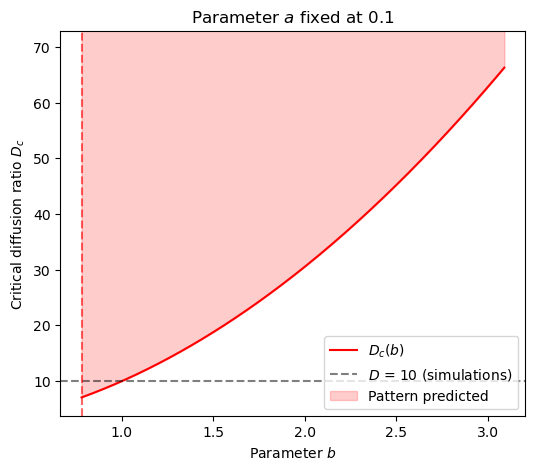

In [5]:
Dc_vals = []
a_fixed = 0.1
b_vals = np.arange(a_fixed * 1.1, a_fixed + 3, 0.01)

for b_i in b_vals:
    Dc_vals.append(critical_D(a=a_fixed, b=b_i, gamma=gamma))

ax1 = plot_threshold_slice(b_vals=b_vals, Dc_vals=Dc_vals,
                           a=a_fixed, D_sim=D,
                           )

Critical Diffusion ratio (D_c) for a=0.10 & b=0.90 is 8.57


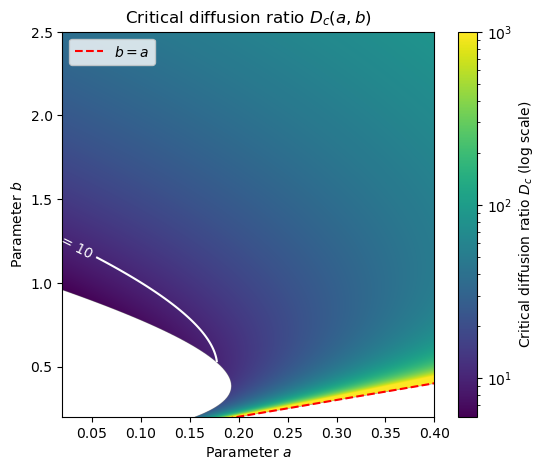

In [ ]:
a_vals = np.linspace(0.02, 0.4, 2500)
b_vals = np.linspace(0.2, 2.5, 2500)
Dc_grid = np.full((len(b_vals), len(a_vals)), np.nan)

for i, b_i in enumerate(b_vals):
    for j, a_i in enumerate(a_vals):
        Dc_grid[i, j] = critical_D(a=a_i, b=b_i, gamma=gamma)
        
ax2 = plot_threshold_map(
    a_vals=a_vals, b_vals=b_vals,
    Dc_grid=Dc_grid, D_sim=D,
                         )
idx_a = np.argmin(np.abs(a_vals - a))
idx_b = np.argmin(np.abs(b_vals - b))
print(rf'Critical Diffusion ratio (D_c) for a={a_vals[idx_a]:.2f} & b={b_vals[idx_b]:.2f} is {Dc_grid[(idx_b, idx_a)]:.2f}')

In [7]:
n = np.arange(1,20)
k_dense = np.linspace(0, 60, 500)
k_modes = (n * np.pi) / L

In [8]:
growth_modes = np.array([
    growth_rate_analytical(k=k, a=a, b=b, gamma=gamma, D=D) 
    for k in k_modes
    ])

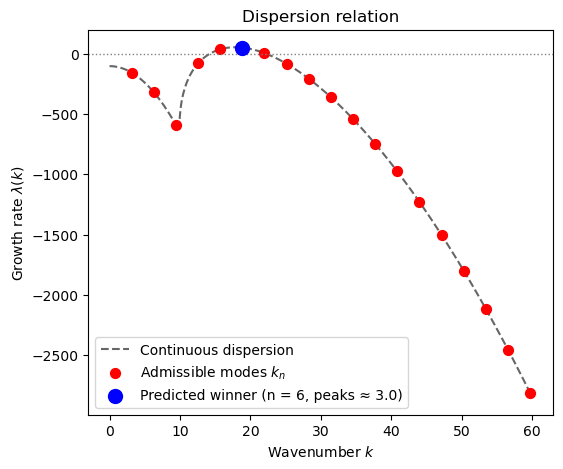

In [9]:
growth = np.array(
    [
        growth_rate_analytical(k=k_val, a=a, b=b, gamma=gamma, D=D)
        for k_val in k_dense
    ])

ax3 = plot_dispersion(k=k_dense, growth= growth, k_modes=k_modes, growth_modes=growth_modes)